<a href="https://colab.research.google.com/github/Hongdao-nn/Portfolio-Projects/blob/main/Customer-Shopping-Preferences-Project/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
from numpy import median
import seaborn as sns
import matplotlib.pyplot as plt

# **Exploratory Data Analysis (EDA) - Customer Shopping Preferences**

## 1. Data Loading & Structural Inspection

**1.1. Loading and Basic Info**



**Objective:** Load the dataset and perform an initial sanity check to understand its dimensions, column names, and data types.

**Key Actions:** Checking .info(), to ensure data integrity.

In [65]:
df = pd.read_csv("customer_shopping_behavior.csv")
# Check the structure (number of rows, number of columns) and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

**Results:**

* The dataset contains **3,900 entries** and **18 columns**.


* Most columns are complete, but `Review Rating` has missing values (**3863 non-null vs 3900 total**).

* Data types are mostly correct (integers for amounts, objects for categories), but we need to handle the missing values before further analysis.

**1.2. Feature Classification**

**Objective:** Categorize variables into Numerical and Categorical groups to streamline the visualization and analysis process.


**Key Actions:**

* Utilize `select_dtypes` to filter columns by data type.

* Store names in two lists: `num_cols` (for integers/floats) and `cat_cols` (for objects).

In [66]:
# Get a list of numerical columns
num_cols = df.select_dtypes (include=['int64', 'float64']).columns
print("Numerical columns:", num_cols)
# Get a list of categorical columns
cat_cols = df.select_dtypes (include=['object']).columns
print("Categorical columns:", cat_cols)

Numerical columns: Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases'],
      dtype='object')
Categorical columns: Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Payment Method', 'Frequency of Purchases'],
      dtype='object')


**Results:**

* **Numerical columns**: `Age`, `Purchase Amount (USD)`, `Review Rating`, and `Previous Purchases`.

* **Categorical columns**: `Gender`, `Category`, `Season`, `Subscription Status`, etc.


**1.3 Check and handle missing values.**

**Objective:** Identify missing information to ensure a complete dataset for analysis.

**Key Actions:** Detect null values using `.isnull().sum().`

In [67]:
# Check the total number of missing values ​​in each column.
print(df.isnull().sum())

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64


**Results:** Apart from the `Review Rating`, which has **37** missing values, the remaining columns have been fully prepared.

**Objective:** After identifying `Review Rating` has missing values, we need to choose an appropriate method to fill it in. Since `Review Rating` is a **numerical column**, using the **Median** method is a safe approach to preserve the central tendency without being influenced by potential extreme ratings.

**Key Actions:**

* Calculate the **Median** of the affected column.

* Fill gaps using the `.fillna()` method to maintain data consistency.

In [68]:
# Calculate the median of the Review Rating column.
median_review_rating = df['Review Rating'].median()
print("Median of Review Rating:", median_review_rating)
# Fill in the median value in the blanks
df['Review Rating'] = df['Review Rating'].fillna(median_review_rating)
# Check the total number of missing values ​​in each column.
df.isnull().sum()

Median of Review Rating: 3.8


,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


**Results:**

* The **Median** is **3.8**, we use it to fill the gaps, ensure the data remains robust for future correlation analysis.

* The dataset is now fully clean with no remaining missing values, ready for descriptive and diagnostic analysis.

## 2. Exploratory Data Analysis (EDA)

**2.1 Descriptive Statistical Analysis**

**Objective:** Perform a comprehensive summary of the dataset to understand the central tendency and dispersion of both numerical and categorical features.

**Key Actions:**

* Use `df.describe(include='all')` to get a holistic view.

* Analyze key metrics such as **Mean**, **Standard Deviation**, and **Quartiles**.

In [69]:
# Summarize all columns
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750538,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.713589,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


**Results:**

**1. Numerical Insights:**

* **Customer Age:** The average age is **44.07** years, with a diverse range from 18 to 70.

* **Spending:** Customers spend an average of **$59.76** per transaction.

* **Customer Loyalty:** On average, a customer has made **25.35** previous purchases, showing a high level of repeat business.

* **Review Ratings:** After imputation, the average rating is **3.75**, with the lowest rating being **2.5**. This indicates generally positive feedback from shoppers.

**2. Categorical Insights:**

* **Gender Dominance:** Male customers represent the majority with **2,652 entries** (**~68%** of the dataset).

* **Top Category:** Clothing is the most popular category, appearing **1,737** times.

* **Logistics:** Montana is the top location for purchases, and Free Shipping is the most common shipping type used.

* **Shopping Behavior:** Most customers do not use a subscription (Subscription Status: No) and prefer PayPal as their primary payment method.

**2.2 Numerical Distribution Analysis**

**Objective:** Explore the distribution shape of numerical variables and evaluate their symmetry using **Skewness** coefficients. This step is crucial for deciding whether data transformation is needed before modeling.

**Key Actions:**

* Visualize distributions using **Histograms** with **KDE** (Kernel Density Estimate) overlays.

* Mathematically verify symmetry by calculating the **Skewness** for each feature.

Skewness of Age: -0.01
Skewness of Purchase Amount (USD): 0.01
Skewness of Review Rating: -0.00
Skewness of Previous Purchases: 0.00


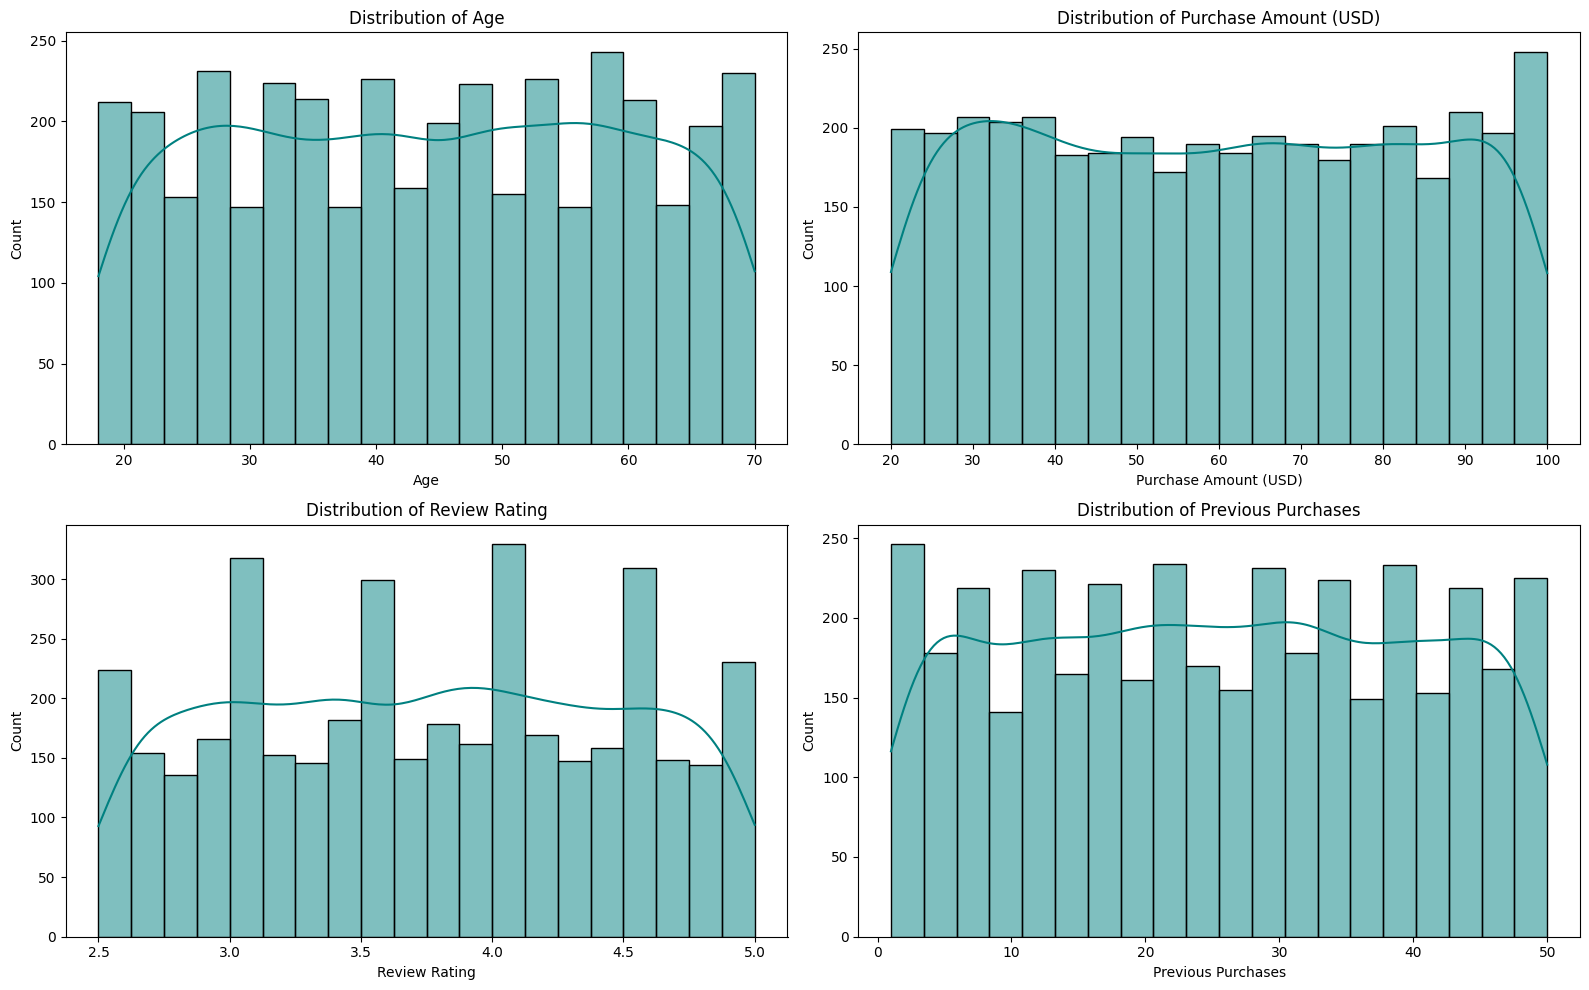

In [70]:
# List of found numerical columns (excluding Customer ID as it is not statistically significant)num_viz_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
num_viz_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_viz_cols):
    plt.subplot(2, 2, i+1)
# Draw a histogram combined with the KDE line to see the deviation.
    sns.histplot(df[col], kde=True, color='teal', bins=20)
    plt.title(f'Distribution of {col}')
    # Add Skewness data to confirm the claim.
    print(f"Skewness of {col}: {df[col].skew():.2f}")
plt.tight_layout()
plt.show()

**Results:**

* `Age` (**Skew: -0.01**): The distribution is nearly perfectly symmetrical. The slight negative skew is negligible, indicating an even spread across all age groups from **18** to **70**.


* `Purchase Amount (USD)` (**Skew: 0.01**): Almost zero skewness suggests that the spending amounts are uniformly distributed without being heavily biased toward very high or very low values.


* `Review Rating` (**Skew: -0.00**) & `Previous Purchases` (**Skew: 0.00**): These variables show perfect symmetry. This is particularly interesting for Review Rating, as it implies a balanced sentiment across the customer base.

All primary numerical features exhibit **Normal-like distribution (Gaussian distribution)**.
* **No Transformation Required**: Since the skewness is within the range of $[-0.5, 0.5]$, the data does not require log transformation or scaling for symmetry purposes.
* **Modeling Advantage**: Many machine learning algorithms perform better with normally distributed data, which makes this dataset an excellent candidate for predictive modeling.

**2.3. Outlier Detection with IQR & Boxplots**

**Objective:** Identify potential anomalies or extreme values that could distort statistical summaries or negatively impact machine learning models.

**Key Actions:**
* Calculate the **IQR** (Interquartile Range) and define boundaries using the $1.5 \times IQR$ rule.

* **Visual Approach:** Utilize **Boxplots** (Whisker plots) to visually inspect data points outside the calculated fences.

Column Age has no outliers.
Column Purchase Amount (USD) has no outliers.
Column Review Rating has no outliers.
Column Previous Purchases has no outliers.


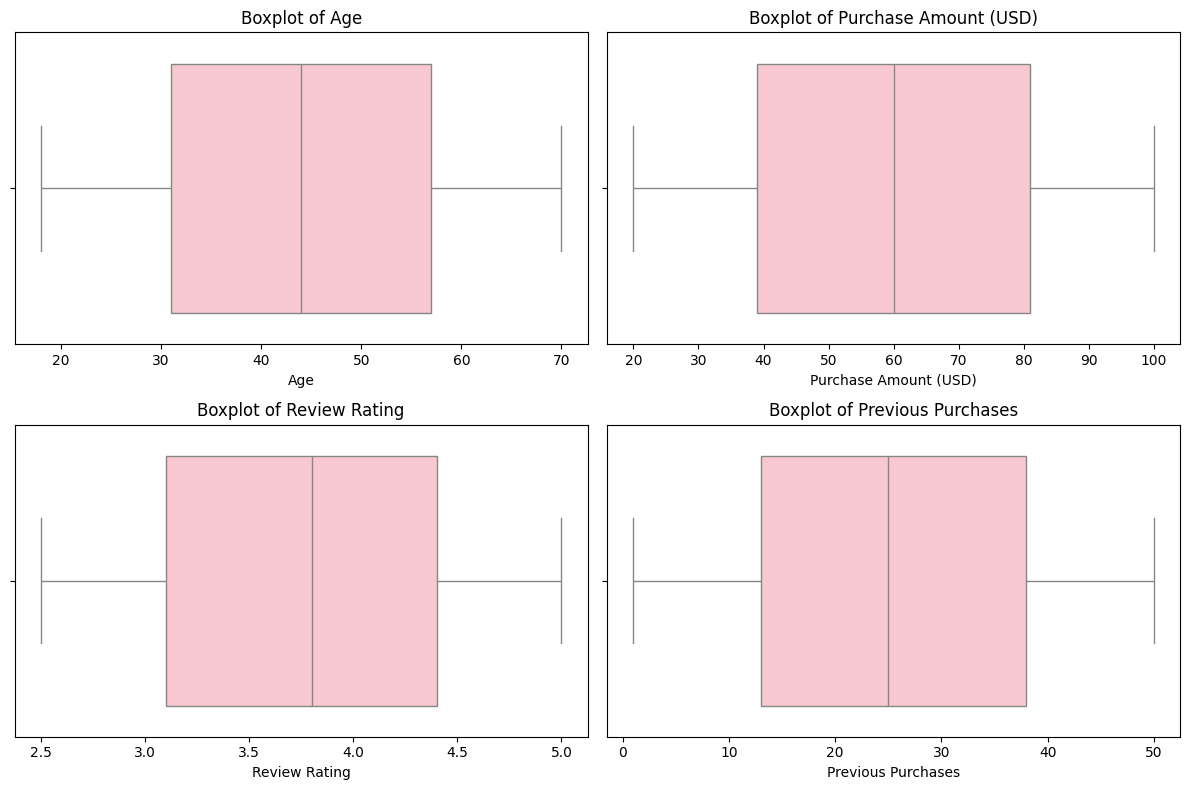

In [71]:
# Select numerical columns to check for outliers
num_viz_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
for col in num_viz_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Count the number.
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f"Column {col} has {len(outliers)} outlier values.")
        print(f"Minimum value: {outliers[col].min()}, Maximum value: {outliers[col].max()}")
        print("-" * 20)
    else:
        print(f"Column {col} has no outliers.")
# Visualization using boxplots
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_viz_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, color='pink')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

**Results:**

* `Age`: No outliers detected. All customers fall within the expected range of 18 to 70 years.

* `Purchase Amount (USD)`: No outliers detected. Spending behavior is consistent across the entire sample.

* `Review Rating` & `Previous Purchases`: No outliers detected.

All numerical columns yielded 0 outliers. This indicates a high level of data quality and consistency. The dataset is clean and preserved in its original state for the next phase of analysis.

**2.4. Categorical Feature Exploration**




**Objective:** Examine the distribution of categorical variables to identify the most significant customer segments and shopping patterns.

**Key Actions:**

* Utilize **Count Plots** to visualize the frequency of each category.

* Rank the data in descending order to highlight the most dominant groups.

* Focus on key drivers: `Gender`, `Category`, `Subscription Status`, and `Season`.


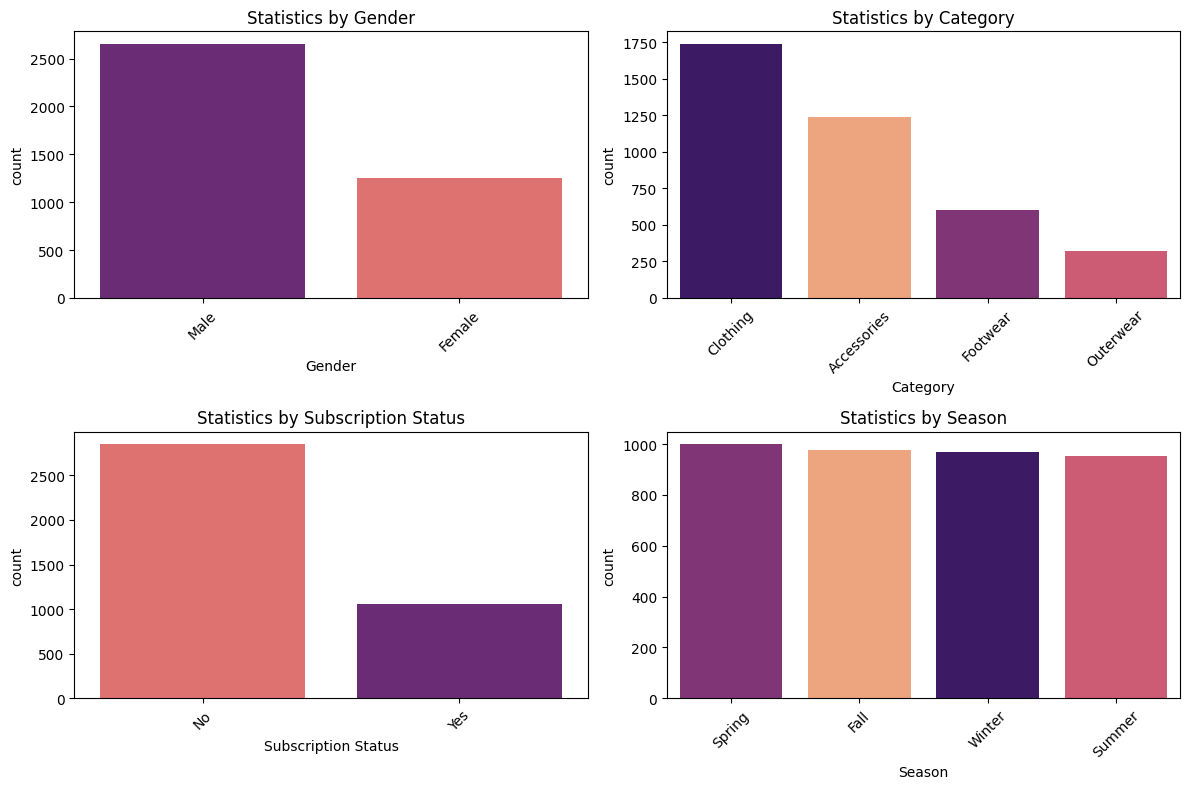

In [72]:
# Select representative categorical columns.
cat_viz_cols = ['Gender', 'Category', 'Subscription Status', 'Season']
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_viz_cols):
    plt.subplot(2, 2, i+1)
    # Draw a bar chart in descending order (from highest to lowest).
    sns.countplot(data=df, x=col, hue=col, palette='magma', order=df[col].value_counts().index, legend=False)
    plt.title(f'Statistics by {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:**

* **1. Gender Distribution:**

The number of **Male** customers is significantly higher (**more than double**) than **Female** customers. The current customer base is heavily male-oriented. Marketing strategies could either double down on this dominant segment or create specific campaigns to attract more female shoppers to balance the ratio.

* **2. Product Category Popularity:**

**Clothing** is the clear winner, followed by **Accessories**. **Footwear** and **Outerwear** trail behind with noticeably lower volumes. Clothing and Accessories are the "bread and butter" of the business. Inventory and floor space (or website real estate) should prioritize these two categories to maximize turnover.

* **3. Subscription Status:**

A vast majority of customers are **not subscribers** (**No**). This represents a massive untapped opportunity. Since these customers are already buying, the business should analyze why they haven't subscribed yet. Implementing a "First-purchase discount for subscribers" could be a high-impact move here.

* **4. Seasonal Purchasing Patterns:**

Sales are remarkably consistent across all four seasons. **Spring** has a very slight edge, but **Fall**, **Winter**, and **Summer** are **almost equal**. This is a very healthy chart. It shows that the business does not suffer from extreme seasonality. The demand is stable year-round, which is great for steady cash flow and predictable supply chain management.

**2.5. Data Preprocessing & Feature Engineering**

**Objective:** Transform raw data into a structured format suitable for machine learning and advanced analytics. This includes encoding categorical variables and normalizing frequency metrics.

**Key Actions:**
* **Mapping Frequency:** Convert text-based `Frequency of Purchases` into numerical annual counts (e.g., Weekly $\rightarrow$ 52).

* **Binary Mapping:** Convert `Subscription Status`, `Discount Applied`, and `Promo Code` Used into $[0, 1]$.

* **Ordinal Mapping:** Encode `Size` into a numerical scale ($1$ to $4$) to preserve its hierarchical nature.

* **Data Export:** Save the cleaned dataset as customer_shopping_cleaned.csv to ensure consistency across future notebooks and SQL databases.

In [73]:
# Check for unique values ​​in the original column.
print(df['Frequency of Purchases'].unique())
print(df['Size'].unique())
print(df['Subscription Status'].unique())
print(df['Discount Applied'].unique())
print(df['Promo Code Used'].unique())

['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']
['L' 'S' 'M' 'XL']
['Yes' 'No']
['Yes' 'No']
['Yes' 'No']


In [74]:
# Map purchase frequency to annual numerical values (Frequency Mapping)
freq_map = {
    'Annually': 1,
    'Quarterly': 4,
    'Fortnightly': 26,
    'Bi-Weekly': 26,
    'Every 3 Months': 4,
    'Once per two years': 0.5,
    'Weekly': 52,
    'Monthly': 12
}
df['Frequency of Purchases'] = df['Frequency of Purchases'].map(freq_map)

# Convert Binary Categorical variables (Yes/No) into 1/0
binary_map = {'Yes': 1, 'No': 0}
df['Subscription Status'] = df['Subscription Status'].map(binary_map)
df['Discount Applied'] = df['Discount Applied'].map(binary_map)
df['Promo Code Used'] = df['Promo Code Used'].map(binary_map)

# Ordinal Encoding for Size
size_map = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
df['Size'] = df['Size'].map(size_map)

# Final verification of data types and non-null counts
print(df.head())
print(df.info())

# Exporting to a new file to maintain a "Single Source of Truth" for Phase 2
df.to_csv('customer_shopping_cleaned.csv', index=False)
print("Cleaned data exported to 'customer_shopping_cleaned.csv'")

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location  Size      Color  Season  Review Rating  Subscription Status  \
0       Kentucky     3       Gray  Winter            3.1                    1   
1          Maine     3     Maroon  Winter            3.1                    1   
2  Massachusetts     1     Maroon  Spring            3.1                    1   
3   Rhode Island     2     Maroon  Spring            3.5                    1   
4         Oregon     2  Turquoise  Spring            2.7                    1   

   Shipping Type  Discount Applied  Promo Co

 **Results:**

* **Categorical to Numerical:** A total of 5 columns were successfully transformed.

* `Frequency of Purchases` is now a continuous variable (Annualized).

* `Size` reflects a scale of **1** to **4.**

* `Subscription Status`, `Discount Applied`, and `Promo Code Used` are now standardized as **1 (Yes)** and **0 (No).**

* The processed data has been saved as customer_shopping_cleaned.csv. This file serves as the **Single Source of Truth** for all subsequent notebooks, ensuring consistency in features and observations.